In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')


In [3]:
df = pd.read_csv('Assortment_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Shape : {df.shape}")
print(f"Période : {df['date'].min()} → {df['date'].max()}")
print(f"Magasins : {df['store_id'].nunique()}")
print(f"Produits : {df['product_id'].nunique()}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()


Shape : (520000, 18)
Période : 2023-01-02 00:00:00 → 2024-12-23 00:00:00
Magasins : 250
Produits : 20

Types :
store_id                        object
region                          object
store_format                    object
shelf_capacity_cm                int64
purchasing_power_idx           float64
date                    datetime64[ns]
product_id                      object
product_name                    object
product_brand                   object
product_category                object
nutriscore                      object
facing_cm                        int64
retail_price_euros             float64
promo_discount_pct             float64
actual_price_euros             float64
unit_margin_euros              float64
is_present                       int64
sales_volume                     int64
dtype: object

Valeurs manquantes :
Series([], dtype: int64)


,store_id,region,store_format,shelf_capacity_cm,purchasing_power_idx,date,product_id,product_name,product_brand,product_category,nutriscore,facing_cm,retail_price_euros,promo_discount_pct,actual_price_euros,unit_margin_euros,is_present,sales_volume
0,STR_001,Ile-de-France,Proxi,146,108.5,2023-01-02,DAN_UF_001,Activia Nature 4x125g,Danone,Ultra-Frais,A,15,1.5,0.15,1.27,0.40,1,116
1,STR_001,Ile-de-France,Proxi,146,108.5,2023-01-02,DAN_UF_002,Danette Chocolat 4x125g,Danone,Dessert,D,20,1.8,0.15,1.53,0.55,1,113
2,STR_001,Ile-de-France,Proxi,146,108.5,2023-01-02,DAN_UF_003,Danone Veloute Fruix 8x125g,Danone,Ultra-Frais,B,25,2.5,0.00,2.50,0.70,1,68
3,STR_001,Ile-de-France,Proxi,146,108.5,2023-01-02,MDD_UF_001,MDD Yaourt Nature 4x125g,MDD,Ultra-Frais,A,12,0.9,0.00,0.90,0.10,1,55
4,STR_001,Ile-de-France,Proxi,146,108.5,2023-01-02,CON_UF_001,Yoplait Panier Fruits 6x125g,Concurrent,Ultra-Frais,B,20,2.2,0.00,2.20,0.25,0,0


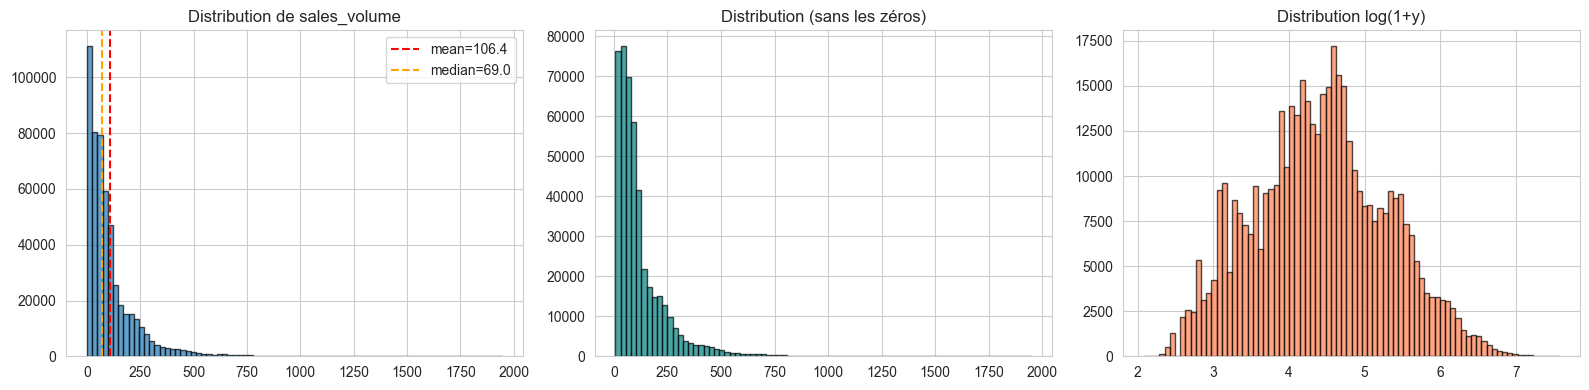

% de zéros : 12.0%
Skewness : 2.88
Kurtosis : 13.44
Mean : 106.4 | Std : 124.0 | Median : 69.0


In [4]:
y = df['sales_volume']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y, bins=80, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution de sales_volume')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'mean={y.mean():.1f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', label=f'median={y.median():.1f}')
axes[0].legend()

axes[1].hist(y[y > 0], bins=80, edgecolor='black', alpha=0.7, color='teal')
axes[1].set_title('Distribution (sans les zéros)')

axes[2].hist(np.log1p(y[y > 0]), bins=80, edgecolor='black', alpha=0.7, color='coral')
axes[2].set_title('Distribution log(1+y)')

plt.tight_layout()
plt.show()

print(f"% de zéros : {(y == 0).mean()*100:.1f}%")
print(f"Skewness : {y.skew():.2f}")
print(f"Kurtosis : {y.kurtosis():.2f}")
print(f"Mean : {y.mean():.1f} | Std : {y.std():.1f} | Median : {y.median():.1f}")


In [5]:
# --- Features temporelles ---
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# --- Indicateur été (saisonnalité eaux) ---
df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)

# --- Taux de présence de la catégorie par magasin/semaine ---
# C'est la feature clé pour capter la cannibalisation
cat_presence = (
    df.groupby(['store_id', 'date', 'product_category'])['is_present']
    .transform('mean')
)
df['category_presence_rate'] = cat_presence

# --- Nombre de produits présents dans la catégorie ---
df['n_present_in_category'] = (
    df.groupby(['store_id', 'date', 'product_category'])['is_present']
    .transform('sum')
)

# --- Total produits dans la catégorie ---
df['n_total_in_category'] = (
    df.groupby(['store_id', 'date', 'product_category'])['is_present']
    .transform('count')
)

# --- Interaction prix × promo ---
df['price_after_promo'] = df['retail_price_euros'] * (1 - df['promo_discount_pct'])

# --- Flag marque premium vs MDD ---
premium_brands = ['Danone', 'Alpro', 'HiPRO', 'Evian', 'Volvic', 'Actimel', 'Danacol']
df['is_premium'] = df['product_brand'].isin(premium_brands).astype(int)

print(f"Features après engineering : {df.shape[1]} colonnes")
df[['store_id', 'date', 'product_name', 'category_presence_rate',
    'n_present_in_category', 'is_premium']].head(20)


Features après engineering : 27 colonnes


,store_id,date,product_name,category_presence_rate,n_present_in_category,is_premium
0,STR_001,2023-01-02,Activia Nature 4x125g,0.750000,3,1
1,STR_001,2023-01-02,Danette Chocolat 4x125g,1.000000,3,1
2,STR_001,2023-01-02,Danone Veloute Fruix 8x125g,0.750000,3,1
3,STR_001,2023-01-02,MDD Yaourt Nature 4x125g,0.750000,3,0
4,STR_001,2023-01-02,Yoplait Panier Fruits 6x125g,0.750000,3,0
5,STR_001,2023-01-02,Alpro Boisson Amande 1L,0.750000,3,1
6,STR_001,2023-01-02,Alpro Dessert Coco 4x125g,0.750000,3,1
7,STR_001,2023-01-02,Bjorg Lait Avoine 1L,0.750000,3,0
8,STR_001,2023-01-02,HiPRO Vanille 160g,1.000000,3,1
9,STR_001,2023-01-02,HiPRO Chocolat 160g,1.000000,3,1


In [6]:
# ========================================================
# POINT CRITIQUE : split temporel, PAS aléatoire
# Un train_test_split(random) = data leakage sur séries temporelles
# ========================================================
CUTOFF_DATE = '2024-07-01'

train = df[df['date'] < CUTOFF_DATE].copy()
test = df[df['date'] >= CUTOFF_DATE].copy()

print(f"Train : {len(train):,} obs ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test  : {len(test):,} obs ({test['date'].min().date()} → {test['date'].max().date()})")
print(f"Ratio : {len(train)/len(df)*100:.0f}% / {len(test)/len(df)*100:.0f}%")

# --- Définition des features ---
cat_cols = ['store_id', 'region', 'store_format', 'product_id',
            'product_brand', 'product_category', 'nutriscore']

num_cols = ['shelf_capacity_cm', 'purchasing_power_idx', 'facing_cm',
            'retail_price_euros', 'promo_discount_pct', 'actual_price_euros',
            'unit_margin_euros', 'is_present', 'year', 'month', 'week_of_year',
            'is_summer', 'category_presence_rate', 'n_present_in_category',
            'n_total_in_category', 'price_after_promo', 'is_premium']

target = 'sales_volume'

feature_cols = cat_cols + num_cols

X_train = train[feature_cols]
y_train = train[target]
X_test = test[feature_cols]
y_test = test[target]

print(f"\nFeatures : {len(feature_cols)} ({len(cat_cols)} cat + {len(num_cols)} num)")


Train : 390,000 obs (2023-01-02 → 2024-06-24)
Test  : 130,000 obs (2024-07-01 → 2024-12-23)
Ratio : 75% / 25%

Features : 24 (7 cat + 17 num)


In [7]:
# OrdinalEncoder pour les tree-based models (XGBoost, LightGBM)
# Ils gèrent nativement les splits sur des entiers

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder.fit(X_train[cat_cols])

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
X_train_enc[cat_cols] = encoder.transform(X_train[cat_cols])
X_test_enc[cat_cols] = encoder.transform(X_test[cat_cols])

# Pour les modèles linéaires : on scale en plus les num
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_enc[num_cols])

print("Encodage OK — pas de NaN :", X_train_enc.isnull().sum().sum() == 0)


Encodage OK — pas de NaN : True


In [8]:
# Cross-validation temporelle sur le train set
tscv = TimeSeriesSplit(n_splits=4)

models = {
    'Linear Regression': (LinearRegression(), X_train_scaled),
    'Ridge (α=1)': (Ridge(alpha=1.0), X_train_scaled),
    'Lasso (α=1)': (Lasso(alpha=1.0, max_iter=5000), X_train_scaled),
    'Random Forest': (RandomForestRegressor(n_estimators=100, max_depth=15,
                                            n_jobs=-1, random_state=42), X_train_enc),
    'XGBoost': (XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8,
                             n_jobs=-1, random_state=42, verbosity=0), X_train_enc),
    'LightGBM': (LGBMRegressor(n_estimators=300, max_depth=10, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               n_jobs=-1, random_state=42, verbose=-1), X_train_enc),
}

results = []

for name, (model, X) in models.items():
    scores = cross_val_score(model, X, y_train, cv=tscv,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    mae = -scores.mean()
    std = scores.std()
    results.append({'Model': name, 'CV MAE': mae, 'Std': std})
    print(f"{name:30s} → MAE = {mae:.2f} ± {std:.2f}")

results_df = pd.DataFrame(results).sort_values('CV MAE')
results_df


/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_m

Linear Regression              → MAE = 43.01 ± 1.38


/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ 

Ridge (α=1)                    → MAE = 43.01 ± 1.38


/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/davidroufe/Library/Python/3.9/lib/python/site-packages/sklearn/linear_m

Lasso (α=1)                    → MAE = 42.86 ± 1.34
Random Forest                  → MAE = 9.26 ± 0.19
XGBoost                        → MAE = 10.07 ± 0.45
LightGBM                       → MAE = 9.30 ± 0.14


,Model,CV MAE,Std
3,Random Forest,9.255661,0.189061
5,LightGBM,9.304914,0.138534
4,XGBoost,10.069741,0.448801
2,Lasso (α=1),42.860584,1.339211
0,Linear Regression,43.008545,1.375688
1,Ridge (α=1),43.013070,1.378336


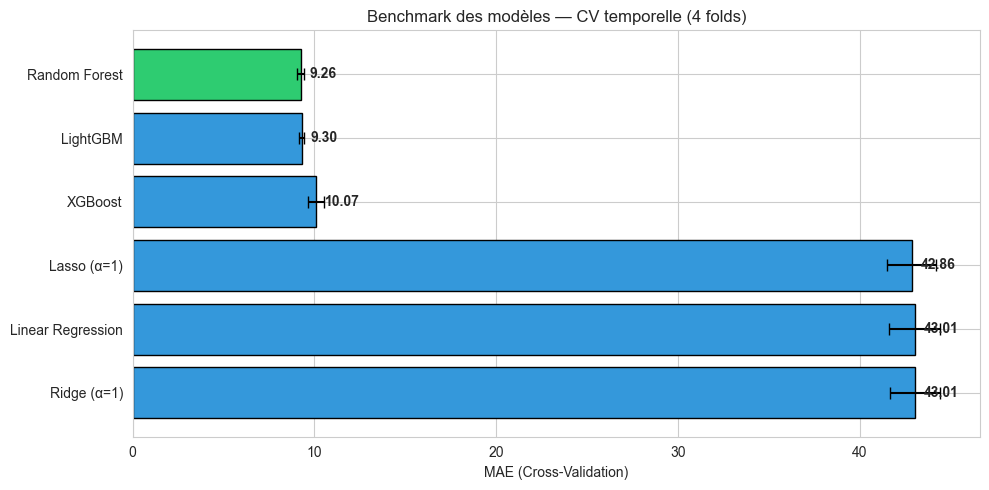

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if i == results_df['CV MAE'].idxmin() else '#3498db'
          for i in results_df.index]
bars = ax.barh(results_df['Model'], results_df['CV MAE'], xerr=results_df['Std'],
               color=colors, edgecolor='black', capsize=4)
ax.set_xlabel('MAE (Cross-Validation)')
ax.set_title('Benchmark des modèles — CV temporelle (4 folds)')
ax.invert_yaxis()
for bar, val in zip(bars, results_df['CV MAE']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# ========================================================
# Entraînement du modèle retenu : Random Forest
# ========================================================
rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
rf_final.fit(X_train_enc, y_train)

y_pred = rf_final.predict(X_test_enc)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Random Forest — Évaluation sur le Test Set (post-juillet 2024) ===")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


=== Random Forest — Évaluation sur le Test Set (post-juillet 2024) ===
MAE  : 12.72
RMSE : 33.10
R²   : 0.9309


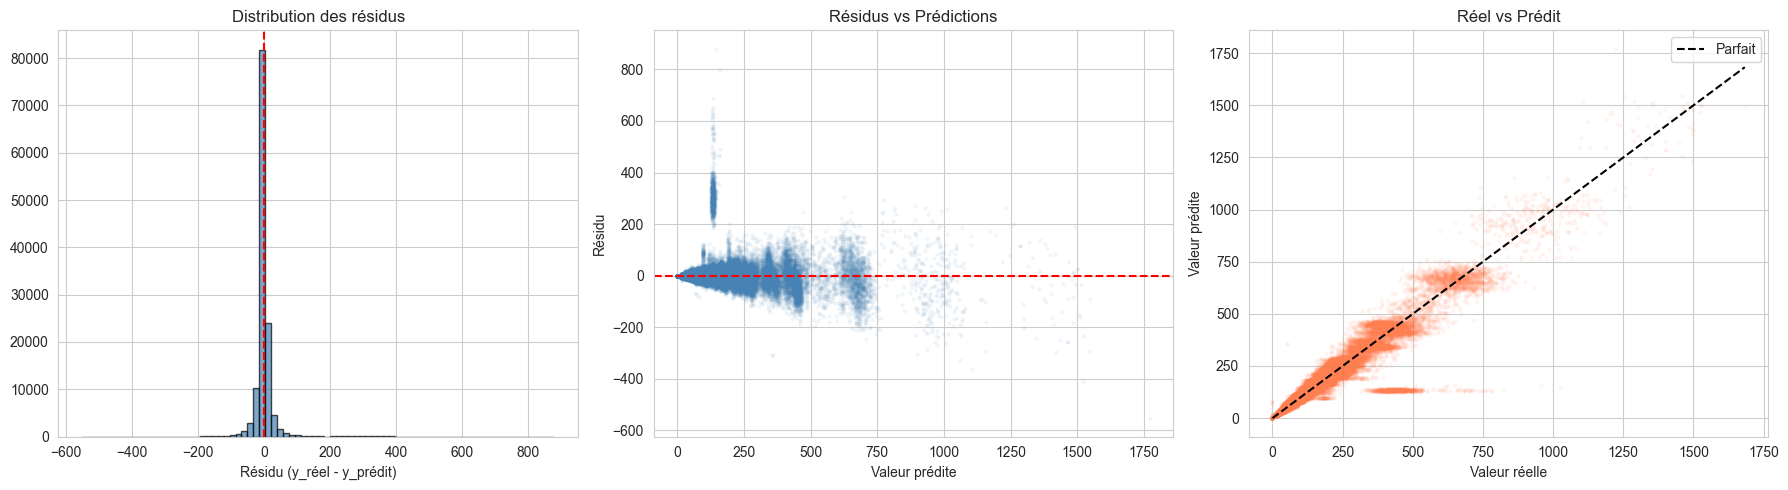

In [11]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution des résidus
axes[0].hist(residuals, bins=80, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution des résidus')
axes[0].set_xlabel('Résidu (y_réel - y_prédit)')

# Résidus vs Prédictions
axes[1].scatter(y_pred, residuals, alpha=0.05, s=5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Résidus vs Prédictions')
axes[1].set_xlabel('Valeur prédite')
axes[1].set_ylabel('Résidu')

# y_réel vs y_prédit
axes[2].scatter(y_test, y_pred, alpha=0.05, s=5, color='coral')
axes[2].plot([0, y_test.max()], [0, y_test.max()], 'k--', label='Parfait')
axes[2].set_title('Réel vs Prédit')
axes[2].set_xlabel('Valeur réelle')
axes[2].set_ylabel('Valeur prédite')
axes[2].legend()

plt.tight_layout()
plt.show()


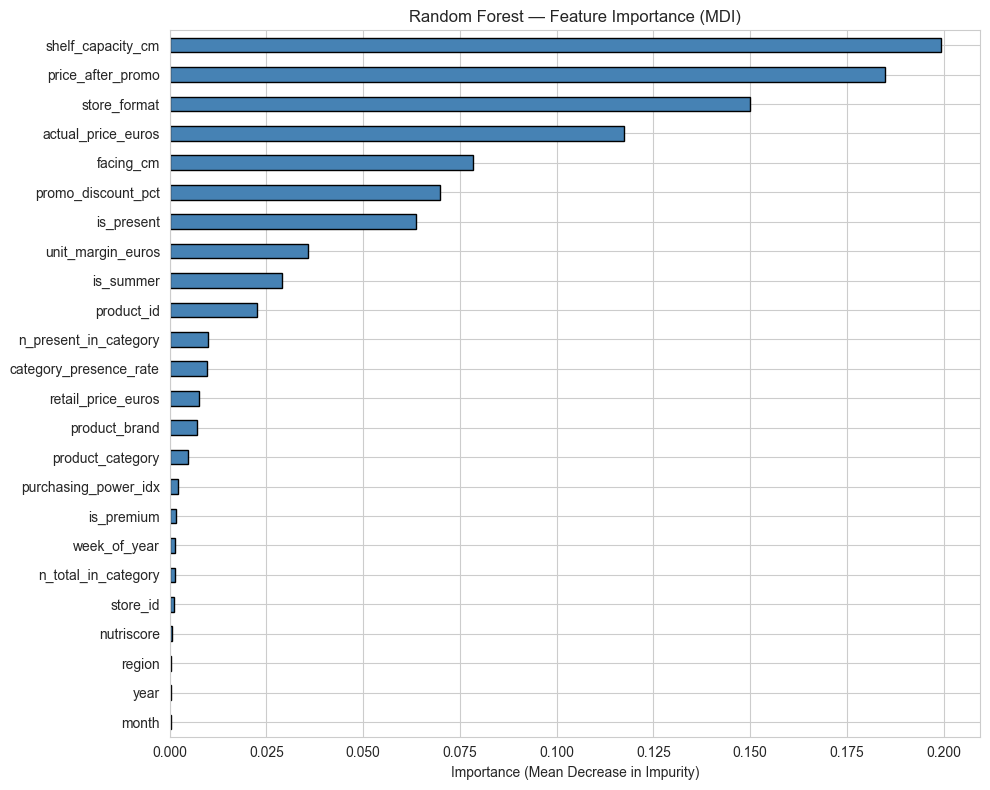

In [12]:
feat_imp = pd.Series(rf_final.feature_importances_, index=X_train_enc.columns)
feat_imp = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest — Feature Importance (MDI)')
plt.tight_layout()
plt.show()


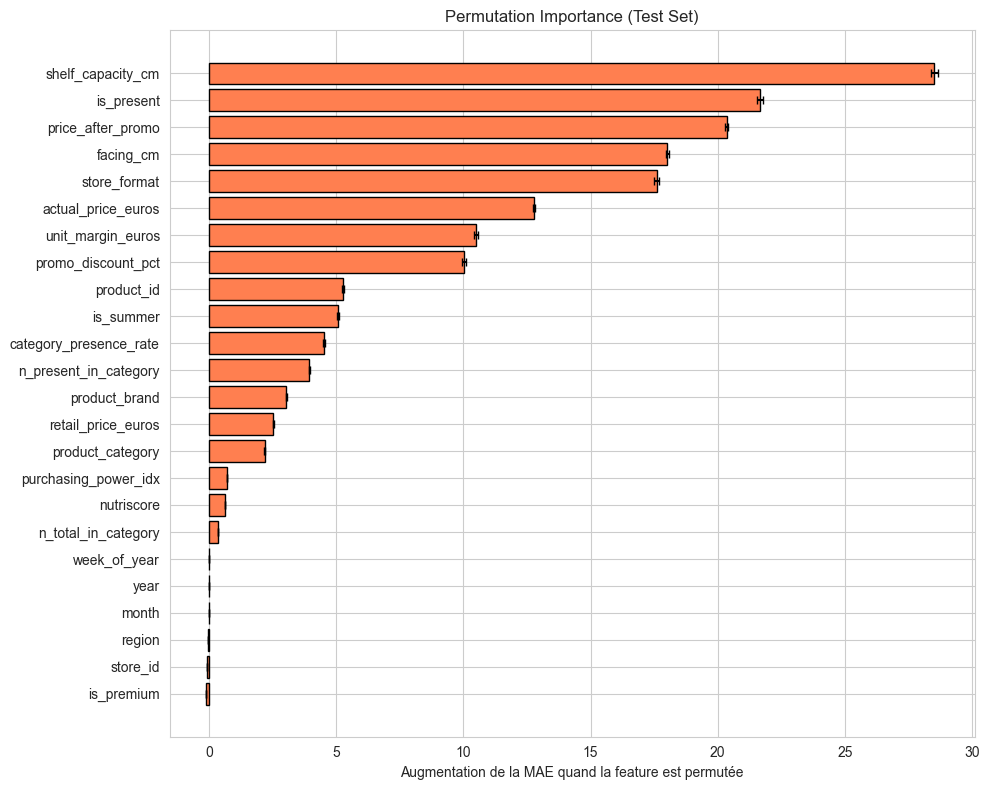

In [13]:
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    rf_final, X_test_enc, y_test,
    n_repeats=10,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test_enc.columns,
    'importance_mean': perm_imp.importances_mean,
    'importance_std': perm_imp.importances_std
}).sort_values('importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(perm_df['feature'], perm_df['importance_mean'],
        xerr=perm_df['importance_std'], color='coral', edgecolor='black', capsize=3)
ax.set_xlabel('Augmentation de la MAE quand la feature est permutée')
ax.set_title('Permutation Importance (Test Set)')
plt.tight_layout()
plt.show()


In [ ]:
explainer = shap.TreeExplainer(rf_final)

X_sample = X_test_enc.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Beeswarm plot
shap.summary_plot(shap_values, X_sample, plot_type='dot', show=False)
plt.title('SHAP — Impact directionnel de chaque feature')
plt.tight_layout()
plt.show()

# Bar plot
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP — Importance moyenne absolue')
plt.tight_layout()
plt.show()


In [ ]:
# ========================================================
# EXPLICABILITÉ : Test de cannibalisation
# On prend un magasin, on force is_present=0 pour la Danette,
# et on observe si le modèle prédit une hausse pour les autres
# produits de la même catégorie (Dessert).
# ========================================================

store = 'STR_001'
test_date = test['date'].max()

# Filtrer les produits Dessert du magasin à cette date
mask = (test['store_id'] == store) & (test['date'] == test_date) & (test['product_category'] == 'Dessert')
dessert_rows = test[mask].copy()

print("=== Situation initiale (Desserts, STR_001) ===")
print(dessert_rows[['product_name', 'is_present', 'sales_volume']].to_string(index=False))

# Encodage pour prédiction
dessert_enc = dessert_rows[feature_cols].copy()
dessert_enc[cat_cols] = encoder.transform(dessert_enc[cat_cols])

pred_baseline = rf_final.predict(dessert_enc)

# Forcer is_present = 0 pour la Danette
dessert_modified = dessert_enc.copy()
danette_mask = dessert_rows['product_name'].str.contains('Danette')
dessert_modified.loc[danette_mask.values, 'is_present'] = 0

# Recalculer le taux de présence de la catégorie
total = len(dessert_modified)
present = dessert_modified['is_present'].sum()
dessert_modified['category_presence_rate'] = present / total
dessert_modified['n_present_in_category'] = int(present)

pred_modified = rf_final.predict(dessert_modified)

# Comparaison
comparison = pd.DataFrame({
    'Produit': dessert_rows['product_name'].values,
    'is_present (avant)': dessert_rows['is_present'].values,
    'is_present (après)': dessert_modified['is_present'].values,
    'Prédiction avant': np.round(pred_baseline, 1),
    'Prédiction après': np.round(pred_modified, 1),
    'Δ Volume': np.round(pred_modified - pred_baseline, 1)
})

print("\n=== Effet de retirer la Danette du rayon ===")
print(comparison.to_string(index=False))
print(f"\nLa Danette perd tout son volume.")
print("Les autres produits Dessert (La Laitière, MDD Mousse Chocolat)")
print("devraient voir leurs ventes AUGMENTER → c'est la cannibalisation captée par le modèle.")
